## Problem 3 part A
1. Generate Erdos-Renyi G(n=150,p=0.08).
2. Analyze:
    - number and size of connected components
    - histograms for: degree value, closeness, and betweenness centralities
    - normalize degree histogram and plot Poisson PMS over it (scipy.stats.poisson)
    - compare for different bin numbers. Q Is the bin size important?
`3. Export the network as GraphML file and attributes (centralities, degree) as csv file`
4. Check what happens when different 'p' (no need to hand in)


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats

In [ ]:
# 1. Generate Erdos-Renyi G(n=150,p=0.08).
graph = nx.erdos_renyi_graph(150, 0.08)

In [ ]:
# number and size of connected components
components_list = list(nx.connected_components(graph))
for i in range(len(components_list)):
  print(">> component", i, "of size", len(components_list[i]))
print("# Total of", len(components_list), "components")

>> component 0 of size 150
# Total of 1 components


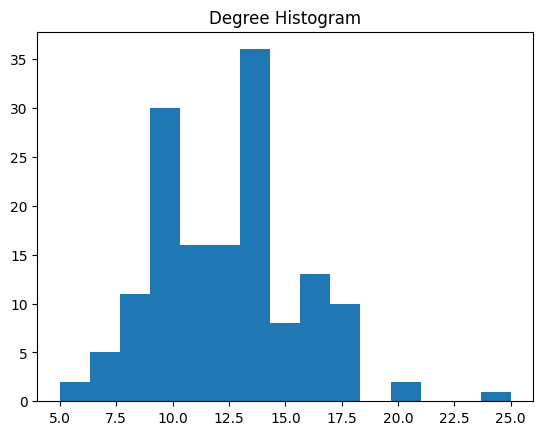

In [ ]:
# histograms for: degree value, closeness, and betweenness centralities
degree_list = list(dict(graph.degree).values())
plt.hist(degree_list, bins = 15)
plt.title("Degree Histogram")
plt.savefig("degree_histogram.png")
plt.show()

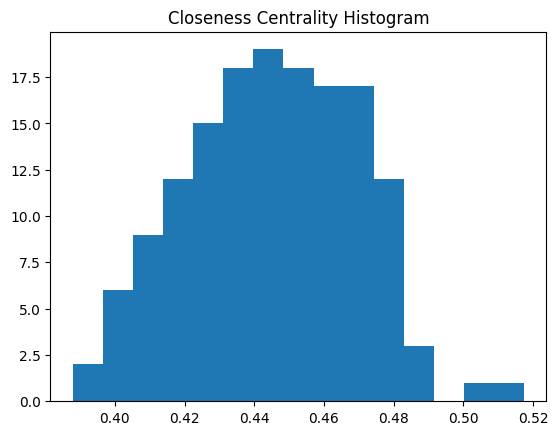

In [ ]:
# closeness_centrality
closeness_centrality = nx.closeness_centrality(graph)
closeness_centrality_list = list(closeness_centrality.values())
plt.hist(closeness_centrality_list, bins = 15)
plt.title("Closeness Centrality Histogram")
plt.savefig("closeness_centrality_histogram.png")
plt.show()

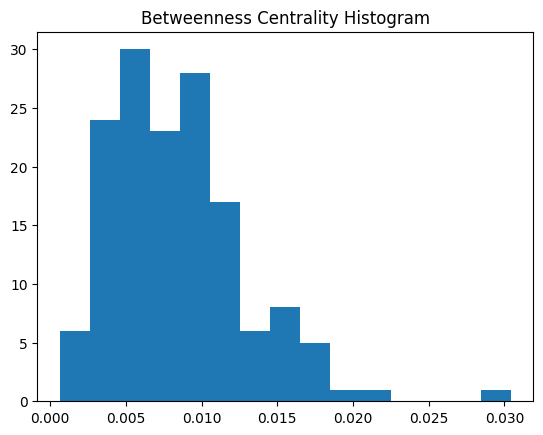

In [ ]:
# betweenness_centrality
betweenness_centrality = nx.betweenness_centrality(graph)
betweenness_centrality_list = list(betweenness_centrality.values())
plt.hist(betweenness_centrality_list, bins = 15)
plt.title("Betweenness Centrality Histogram")
plt.savefig("betweenness_centrality_histogram.png")
plt.show()

In [ ]:
sample_mean = np.mean(list(degree_list))
sample_mean

np.float64(12.266666666666667)

In [ ]:
poisson_list = scipy.stats.poisson.rvs(size=150, mu = sample_mean, random_state=13)
print("poisson", poisson_list)
print("degrees", np.array(degree_list))

poisson [15 13 14 11  9 20 16 14 15 10 18 12 11 15 14  8  9 18  9 13 16  8 12 12
 18  8 13 21  8  9 12 22 16  7 22  6 14 10 16 14  9 15  7 10  9 15 13 16
 13  8 13 20 11  6 15 11 10 10 14 13 12 11  7 16 15 18 18  8 10  8 10 19
  7  8 10 10  7 16 10 18 12  9 17  8 13  8 18  9 10 15 10  7 16 13 10 12
 16  8 10 11  5 13 12 16 18  9 13 12  9 12  9  5 12 16 17 13  9 11 10  9
 10 15 14  9 15  8 11  9 16  7 11  8 15 14 17 14 10 12  8 12 15  9 13 18
  9 12 14 20 12 12]
degrees [13 16 12 14  9 11 13 10 16 17  9 12 12 11 13 14  8 16 16  8 13 13 10 14
 15 18 13 13 10 11  9 13 18 10  8 10 16  9 14 12  8  8 14 12 14 11 11 13
 12 11  9  7  9 14 12 20 14 18 11 13 13  9 11 13 16 15  9 11 10 13 12 14
 10 12 13 10  8 10 13 13 14 18 10 14 12 18  8 13 16 15 12  9 10 15 25 16
 12  5 10  7 16  8 17 13 16  9 12 12 18  7 10 13 10  8 17 10 16 11 12 13
 15 11  7 16 12  5 10 15 14 11 17  9 20  8 11 16 10  7 11  8 15  9 10 11
 14 13 14 15 11 13]


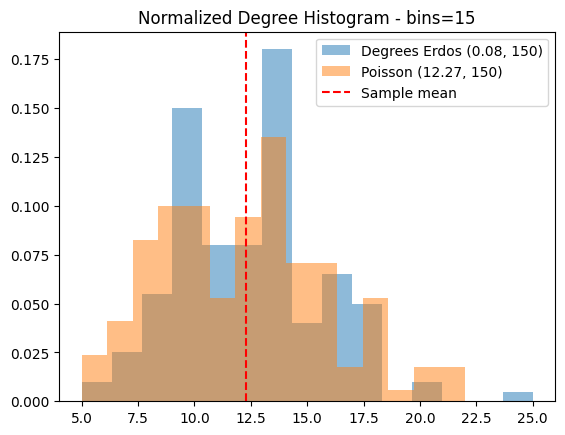

In [ ]:
# normalize degree histogram and plot Poisson PMS over it (scipy.stats.poisson)
plt.hist(degree_list, bins = 15, density=True, alpha=0.5, label="Degrees Erdos (0.08, 150)")
plt.hist(poisson_list, bins = 15, density=True, alpha=0.5,label=f"Poisson ({sample_mean:.2f}, 150)")
plt.axvline(x=sample_mean, color='red', linestyle='--', label="Sample mean")
plt.title("Normalized Degree Histogram - bins=15")
plt.legend()
plt.savefig("normalized_degree_histogram.png")
plt.show()

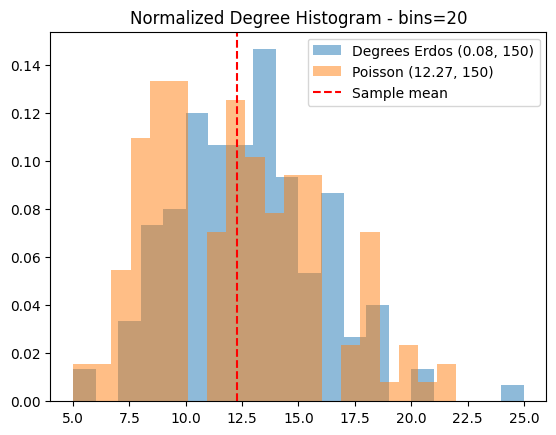

In [ ]:
# normalize degree histogram and plot Poisson PMS over it (scipy.stats.poisson)
bin_count = 20
plt.hist(degree_list, bins = bin_count, density=True, alpha=0.5, label="Degrees Erdos (0.08, 150)")
plt.hist(poisson_list, bins = bin_count, density=True, alpha=0.5,label=f"Poisson ({sample_mean:.2f}, 150)")
plt.axvline(x=sample_mean, color='red', linestyle='--', label="Sample mean")
plt.title(f"Normalized Degree Histogram - bins={bin_count}")
plt.legend()
plt.savefig("normalized_degree_histogram_20.png")
plt.show()

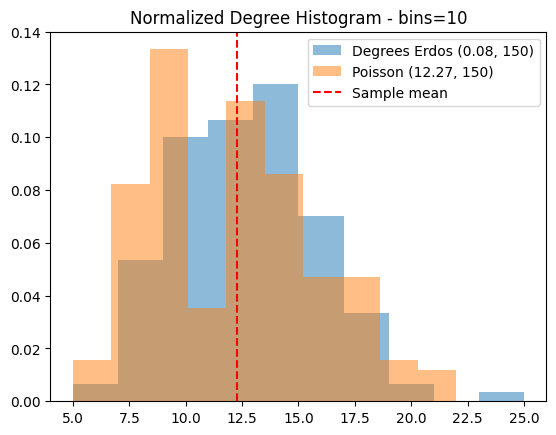

In [ ]:
# normalize degree histogram and plot Poisson PMS over it (scipy.stats.poisson)
bin_count = 10
plt.hist(degree_list, bins = bin_count, density=True, alpha=0.5, label="Degrees Erdos (0.08, 150)")
plt.hist(poisson_list, bins = bin_count, density=True, alpha=0.5,label=f"Poisson ({sample_mean:.2f}, 150)")
plt.axvline(x=sample_mean, color='red', linestyle='--', label="Sample mean")
plt.title(f"Normalized Degree Histogram - bins={bin_count}")
plt.legend()
plt.savefig("normalized_degree_histogram_10.png")
plt.show()

In [ ]:
# 3. Export the network as GraphML file and attributes (centralities, degree) as csv file
df_attributes = pd.DataFrame([degree_list, closeness_centrality_list, betweenness_centrality_list]).T
df_attributes.columns = ["degree", "closeness", "betweenness"]
df_attributes


,degree,closeness,betweenness
0,13.0,0.454268,0.008159
1,16.0,0.470032,0.014706
2,12.0,0.443452,0.007626
3,14.0,0.465625,0.009047
4,9.0,0.413889,0.003699
...,...,...,...
145,13.0,0.443452,0.010045
146,14.0,0.470032,0.010469
147,15.0,0.465625,0.015357
148,11.0,0.438235,0.006531


In [ ]:
nx.write_graphml(graph, "erdos08_150.graphml")
df_attributes.to_csv("erdos08_150_attributes.csv", float_format='%.4f')


## Problem 1

Consider RPKM table. Draw edges if:
1. Euclidian distance < 11
2. correlation coefficient > 0.75. And Color positive RED and negative BLUE
3. L1 form < 20
4. mutual information > 0.65. Bin each gene into 3 intervals. Show MI vals as edge weights.


In [ ]:
RPKM_table = {
    'A':[7, 9.2,  14.6, 20, 35.1 ],
    'B':[19,  14.2, 6.6,  14.6, 18],
    'C':[8.6, 7,  6.5,  7.3,  8.7],
    'D':[6.8, 7.9,  5.5,  2.3,  2.9],
    'E':[0.9, 1.8,  3.9,  4.8,  6.2]
}
RPKM_table

{'A': [7, 9.2, 14.6, 20, 35.1],
 'B': [19, 14.2, 6.6, 14.6, 18],
 'C': [8.6, 7, 6.5, 7.3, 8.7],
 'D': [6.8, 7.9, 5.5, 2.3, 2.9],
 'E': [0.9, 1.8, 3.9, 4.8, 6.2]}

In [ ]:
graph = nx.Graph()
graph.add_nodes_from(RPKM_table.keys())
graph.nodes

NodeView(('A', 'B', 'C', 'D', 'E'))

In [ ]:
from sklearn.metrics import mutual_info_score

def rule_euclidian_dist(geneA, geneB, trashold):
  sum = 0
  for expA, expB in zip(geneA, geneB):
    sum += (expA-expB)**2
  #print("euclidian distance is", np.sqrt(sum))
  res = np.sqrt(sum)
  return ( res < trashold, res)

def rule_corrcoef(geneA, geneB, trashold):
  res = np.corrcoef(geneA, geneB)
  #print("corrcoef is", res)
  return (abs(res[0,1]) > trashold, res[0,1])

def rule_L1(geneA, geneB, trashold):
  sum = 0
  for expA, expB in zip(geneA, geneB):
    sum += abs(expA-expB)
  return (sum < trashold, sum)

def rule_mutual_info(geneA, geneB, trashold):
  for expA, expB in zip(geneA, geneB):
    res = mutual_info_score(geneA, geneB)
  return (res > trashold, res)


In [ ]:
def draw_graph_if(graph, RPKM_table, rule, trashold):
  graph_copy = graph.copy()
  for geneA in RPKM_table.items():
    for geneB in RPKM_table.items():
      if rule(geneA[1], geneB[1], trashold)[0]:
        graph_copy.add_edge(geneA[0], geneB[0])
  return graph_copy

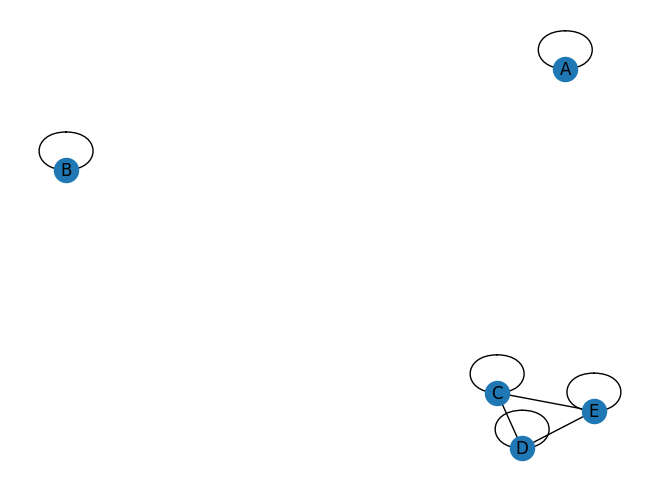

In [ ]:
graph_eucl = draw_graph_if(graph, RPKM_table, rule_euclidian_dist, 11)
nx.draw(graph_eucl, with_labels=True)
plt.savefig("graph_eucl.png",format="PNG", dpi=300)

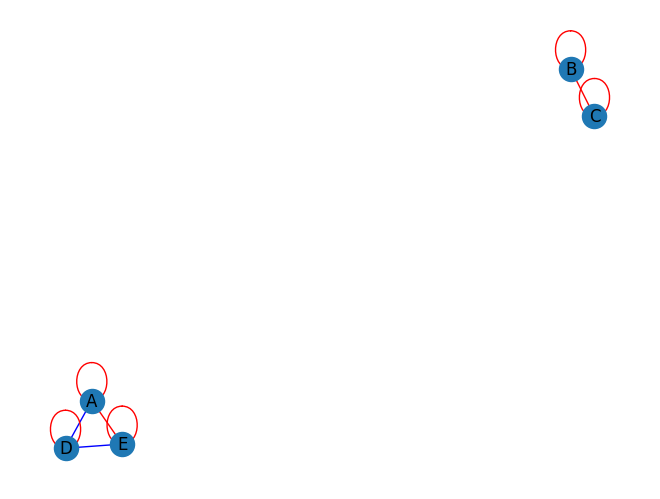

In [ ]:
graph_corrcoef = graph.copy()

for geneA_name, geneA_data in RPKM_table.items():
    for geneB_name, geneB_data in RPKM_table.items():
        is_correlated, coeff = rule_corrcoef(geneA_data, geneB_data, 0.75)

        if is_correlated:
            edge_color = 'red' if coeff > 0 else 'blue'
            graph_corrcoef.add_edge(geneA_name, geneB_name, color=edge_color)

# CHat GPT code:
# --- THE FIX FOR DRAWING ---
# 1. Extract the colors into a list in the order of the edges
colors = [graph_corrcoef[u][v]['color'] for u, v in graph_corrcoef.edges()]

# 2. Pass that list to the edge_color parameter
nx.draw(graph_corrcoef,
        with_labels=True,
        edge_color=colors)
plt.savefig("graph_corrcoef.png",format="PNG", dpi=300)

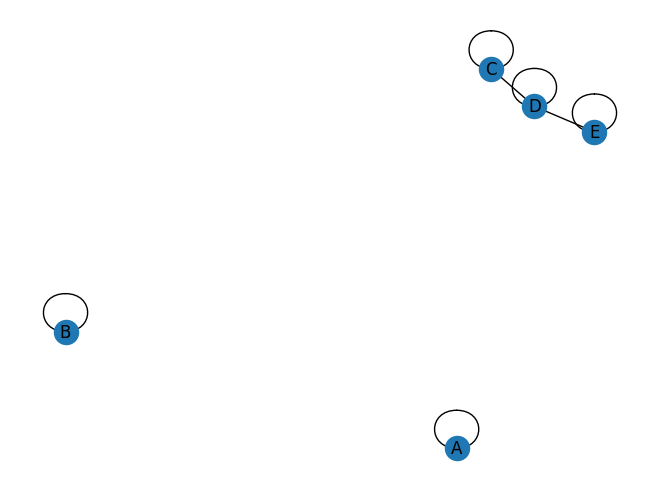

In [ ]:
graph_L1 = draw_graph_if(graph, RPKM_table, rule_L1, 20)
nx.draw(graph_L1, with_labels=True)
plt.savefig("graph_L1.png",format="PNG", dpi=300)

In [ ]:
# bin the RPKM values for each gene into 3 intervals
# decision: take min,max of each gene and create same-width bins. Therefore we consider relative change in expression.
RPKM_table_binned = {}
for gene_name, gene_data in RPKM_table.items():
  # print(gene_name, gene_data)
  expr_min = np.min(gene_data)
  expr_max = np.max(gene_data)
  bins = np.arange(expr_min, expr_max, (expr_max-expr_min)/3)
  bins = np.append(bins, expr_max) # +1 to right bound generated too many bins if step was small enough
  binned_vals = pd.cut(gene_data, bins, right=True, include_lowest=True, labels=[0,1,2])
  # binned_vals_rel = binned_vals.value_counts()/len(binned_vals)
  RPKM_table_binned[gene_name] = binned_vals
RPKM_table_binned

{'A': [0, 0, 0, 1, 2]
 Categories (3, int64): [0 < 1 < 2],
 'B': [2, 1, 0, 1, 2]
 Categories (3, int64): [0 < 1 < 2],
 'C': [2, 0, 0, 1, 2]
 Categories (3, int64): [0 < 1 < 2],
 'D': [2, 2, 1, 0, 0]
 Categories (3, int64): [0 < 1 < 2],
 'E': [0, 0, 1, 2, 2]
 Categories (3, int64): [0 < 1 < 2]}

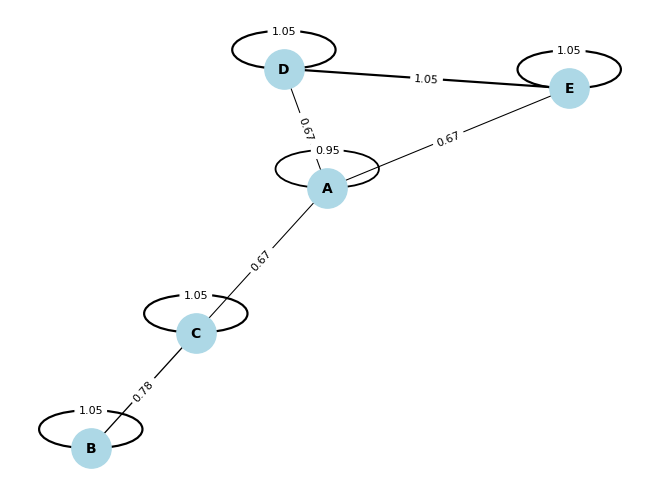

In [ ]:
graph_MI = graph.copy()
for geneA in RPKM_table_binned.items():
  for geneB in RPKM_table_binned.items():
    predicate, value = rule_mutual_info(geneA[1], geneB[1], 0.65)
    if predicate:
      graph_MI.add_edge(geneA[0], geneB[0], weight=value)


# Chat GPT code:

# Calculate positions (Spring layout is standard for networks)
pos = nx.spring_layout(graph_MI)

# Get the literal numbers and format them
# We round to 2 decimal places so the graph isn't messy
edge_weights = nx.get_edge_attributes(graph_MI, 'weight')
formatted_weights = {k: f"{v:.2f}" for k, v in edge_weights.items()}

# Draw the nodes and edges
nx.draw(graph_MI, pos, with_labels=True, node_color='lightblue', width=[(v+0.2)**2 for v in edge_weights.values()],
        node_size=800, font_size=10, font_weight='bold')



thickness = [w * 5 for w in edge_weights]

# 5. Plot the literal numbers onto the edges
nx.draw_networkx_edge_labels(graph_MI, pos, edge_labels=formatted_weights, font_size=8)

plt.savefig("graph_MI.png",format="PNG", dpi=300)
plt.show()
